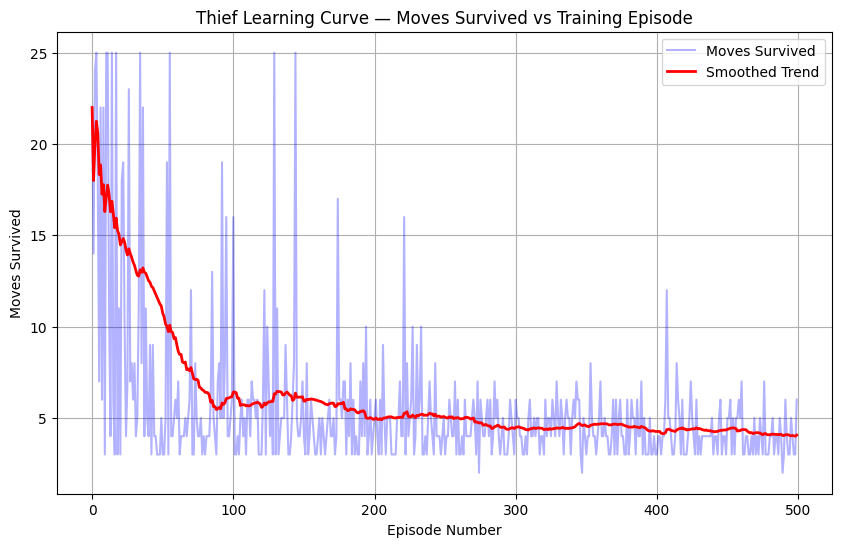

In [1]:
import json
import os
import matplotlib.pyplot as plt

# Load data
episodes = []
moves = []
with open('../results/training_log.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        episodes.append(data['episode'])
        moves.append(data['moves'])

# Calculate smoothed trend line (moving average with window 50)
window = 50
smoothed = []
for i in range(len(moves)):
    start = max(0, i - window + 1)
    smoothed.append(sum(moves[start:i+1]) / (i - start + 1))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(episodes, moves, alpha=0.3, color='blue', label='Moves Survived')
plt.plot(episodes, smoothed, color='red', linewidth=2, label='Smoothed Trend')
plt.title('Thief Learning Curve — Moves Survived vs Training Episode')
plt.xlabel('Episode Number')
plt.ylabel('Moves Survived')
plt.legend()
plt.grid(True)

# Save plot
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/learning_curve.png')
plt.show()
